# Fundamentality of the RAR — Reproduction of Key Figures

This notebook reproduces **Figures 2, 6, and 7** from the paper using the `RARinterpret` library.

- **Figure 2**: Partial correlation coefficients τ(g_obs, x_k | g_bar) with SPARC data vs. Simple IF+EFE and Σ_tot–J_obs mocks  
- **Figure 6**: Loss heatmap for all single/pair feature combinations predicting g_obs with the ET regressor  
- **Figure 7**: Averaged test-set loss for predicting D(α,β) = V_obs^α / r^β across the (α,β) polar grid  

**Note**: The paper uses large numbers of train/test splits (up to 10,000) and mock realizations. This notebook uses reduced parameters for tractability; results are qualitatively identical but will differ numerically from the paper.

## 1. Setup

In [ ]:
import os
import sys
import warnings

# Run from scripts/ so that RARFrame finds '../data/' correctly
os.chdir('/mnt/users/darnej/MPhys/RARinterpret/scripts')
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots  # noqa — registers the 'science' style

from astropy import units
from scipy.optimize import minimize
from scipy.stats import kendalltau, norm
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from tqdm.notebook import tqdm, trange

import RARinterpret

KPC2KM = units.kpc.to(units.km)
os.makedirs('../plots', exist_ok=True)

print('Setup complete.')

## 2. Load SPARC data

In [ ]:
frame = RARinterpret.RARFrame()
print(f'Loaded {len(frame)} data points from {len(np.unique(frame["index"]))} galaxies.')

# Pre-compute quantities used throughout
log_gbar_sparc = np.log10(frame['gbar'])
log_gobs_sparc = np.log10(frame['gobs'])
var_log_gbar   = frame.generate_log_variance('gbar')
var_log_gobs   = frame.generate_log_variance('gobs')

---
## Figure 2 — Partial Correlation Coefficients

We follow `run_pcv2.py`. For each of N_REPEAT mock realisations we:
1. Generate mock V_obs from either the Simple IF+EFE (`SimpleIFEFE`) or Σ–J model (`SJCubic`), keeping real SPARC positions/inclinations/distances.
2. Fit the RARIF interpolating function to the mock g_obs.
3. Compute Kendall's τ between the residuals and every secondary feature.

SPARC is a single run (the data are fixed; the tiny variation from re-fitting is negligible).

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
# Paper: ~500 mock realisations.  Use 50 here for speed (~2 min).
N_REPEAT_PC = 50

PC_FEATURES = [
    'SB', 'type', 'L36', 'SBdisk', 'MHI',
    'inc', 'dist', 'r', 'Reff', 'log_eN_noclust', 'SBbul'
]

# Feature matrix (real SPARC — same for all mock runs)
X_pc, _, _ = frame.make_Xy(target=(2, 1), features=PC_FEATURES)


def compute_pc(log_gbar, log_gobs, X_feats, var_gbar, var_gobs, seed=0):
    """Fit RARIF and return Kendall tau of residuals vs each feature."""
    rng = np.random.default_rng(seed)
    fit_model = RARinterpret.RARIF()
    args = (log_gbar, log_gobs, var_gbar, var_gobs)
    x0 = fit_model.x0 * rng.uniform(0.9, 1.1)
    res = minimize(fit_model, x0, args=args, method='Nelder-Mead',
                   options={'maxiter': 10000, 'xatol': 1e-6})
    residuals = log_gobs - fit_model.predict(log_gbar, res.x)
    corr = np.full((len(PC_FEATURES), 2), np.nan)
    for i in range(len(PC_FEATURES)):
        corr[i, :] = kendalltau(residuals, X_feats[:, i], nan_policy='omit')
    return corr


# ── SPARC (one run) ───────────────────────────────────────────────────────────
print('SPARC partial correlations...')
sparc_pc = compute_pc(
    log_gbar_sparc, log_gobs_sparc, X_pc, var_log_gbar, var_log_gobs
)
print(f'  SPARC τ(g_obs, e_N | g_bar) = {sparc_pc[PC_FEATURES.index("log_eN_noclust"), 0]:.3f}')

In [ ]:
# ── Simple IF + EFE mocks ─────────────────────────────────────────────────────
print(f'Computing {N_REPEAT_PC} Simple IF+EFE mock partial correlations...')
sifefe_gen = RARinterpret.SimpleIFEFE()
sifefe_pc = np.full((N_REPEAT_PC, len(PC_FEATURES), 2), np.nan)

for n in trange(N_REPEAT_PC, desc='SIFEFE mocks'):
    lg_bar, lg_obs, _ = frame.make_Xy(
        target=(2, 1), features=['gbar'],
        gen_model=sifefe_gen, thetas=np.copy(sifefe_gen.x0),
        mock_kind='RAR', seed=n)
    lg_bar = lg_bar.reshape(-1,)
    lg_obs = lg_obs + np.log10(10**13 / KPC2KM)  # unit conversion km/s → m/s

    mask = np.isfinite(lg_obs)  # SIFEFE can produce NaNs for unbound orbits
    sifefe_pc[n] = compute_pc(
        lg_bar[mask], lg_obs[mask], X_pc[mask],
        var_log_gbar[mask], var_log_gobs[mask], seed=n
    )

In [ ]:
# ── Σ_tot – J_obs mocks ───────────────────────────────────────────────────────
print(f'Computing {N_REPEAT_PC} SB-Jobs mock partial correlations...')
sbjobs_gen = RARinterpret.SJCubic()
sbjobs_pc = np.full((N_REPEAT_PC, len(PC_FEATURES), 2), np.nan)

for n in trange(N_REPEAT_PC, desc='SB-Jobs mocks'):
    lg_bar, lg_obs, _ = frame.make_Xy(
        target=(2, 1), features=['gbar'],
        gen_model=sbjobs_gen, thetas=np.copy(sbjobs_gen.x0),
        mock_kind='SB-Jobs', seed=n)
    lg_bar = lg_bar.reshape(-1,)
    lg_obs = lg_obs + np.log10(10**13 / KPC2KM)

    sbjobs_pc[n] = compute_pc(
        lg_bar, lg_obs, X_pc, var_log_gbar, var_log_gobs, seed=n
    )

In [ ]:
# ── Plot Figure 2 ─────────────────────────────────────────────────────────────
# Order features by |median τ| of the SIFEFE mocks (largest first, so the
# most informative features appear on the left)
ordering = np.argsort(
    np.abs(np.median(sifefe_pc[..., 0], axis=0))
)[::-1]
features_ordered = [PC_FEATURES[i] for i in ordering]
xticks = np.arange(1, len(PC_FEATURES) + 1)
quantiles = [norm.cdf(x=[-2, -1, 1, 2])] * len(PC_FEATURES)

with plt.style.context(['science']):
    fig, ax = plt.subplots(figsize=(7, 3.5))

    # SPARC — single red crosses
    ax.scatter(
        xticks, sparc_pc[ordering, 0],
        c='red', marker='x', s=20, label='SPARC', zorder=10
    )

    # Simple IF + EFE mocks — blue violins
    sifefe_rhos = sifefe_pc[:, ordering, 0]
    ax.scatter(
        xticks - 0.05, np.median(sifefe_rhos, axis=0),
        marker='_', s=20, c='C0', label='Simple IF + EFE'
    )
    ax.violinplot(
        sifefe_rhos, positions=xticks - 0.05,
        quantiles=quantiles, showextrema=False
    )

    # Σ_tot – J_obs mocks — green errorbars
    sbjobs_rhos = sbjobs_pc[:, ordering, 0]
    med = np.median(sbjobs_rhos, axis=0)
    ylower = med - np.percentile(sbjobs_rhos, 100 * norm.cdf(-2), axis=0)
    yupper = np.percentile(sbjobs_rhos, 100 * norm.cdf(2), axis=0) - med
    ax.errorbar(
        xticks + 0.05, med, yerr=np.vstack([ylower, yupper]),
        fmt=' ', marker='o', ms=3, c='C2', zorder=-1,
        label=r'$\Sigma_{\rm tot} - J_{\rm obs}$'
    )

    ax.axhline(0, ls='--', c='black', lw=plt.rcParams['axes.linewidth'])
    ax.set_xticks(xticks)
    ax.set_xticklabels(
        RARinterpret.pretty_label(features_ordered, RARinterpret.names),
        rotation=45
    )
    ax.set_ylabel(r'$\tau(g_{\rm obs}, x_k | g_{\rm bar})$')
    ax.legend(ncols=3, loc='upper right', fontsize='x-small',
              columnspacing=0.2, handletextpad=0.1)
    plt.tight_layout()
    plt.savefig('../plots/fig2_partial_correlations.png', dpi=200,
                bbox_inches='tight')
    plt.show()
print('Figure 2 saved to ../plots/fig2_partial_correlations.png')

---
## Figure 2 (TNG) — Partial Correlations from Simulation Data

Load pre-computed results from `results/pc_RARIF_TNG.p` and `results/pc_RARIF_TNG_mock.p` (produced by `job_fig2.sh` on the cluster) and plot the TNG version of Figure 2.

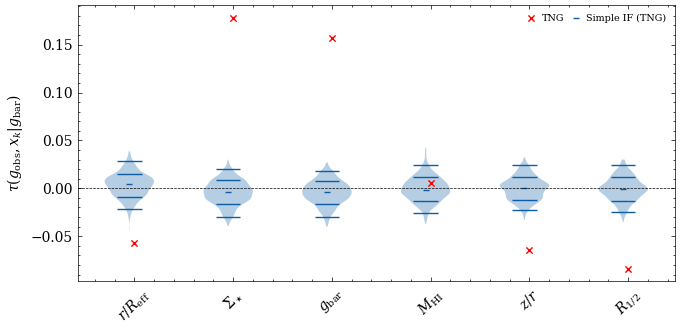

Figure 2 (TNG) saved to /mnt/users/darnej/MPhys/RARinterpret/plots/fig2_partial_correlations_TNG.png


In [3]:
import os, sys
import joblib
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
from scipy.stats import norm

sys.path.insert(0, '/mnt/users/darnej/MPhys/RARinterpret')
import RARinterpret

_results_dir = '/mnt/users/darnej/MPhys/RARinterpret/results'
_plots_dir   = '/mnt/users/darnej/MPhys/RARinterpret/plots'

# ── Load saved TNG results ────────────────────────────────────────────────────
data_tng      = joblib.load(f'{_results_dir}/pc_RARIF_TNG.p')
data_tng_mock = joblib.load(f'{_results_dir}/pc_RARIF_TNG_mock.p')

tng_features  = data_tng['features']       # ['gbar', 'r', 'SB', 'MHI', 'Reff', 'type']
tng_real_corr = data_tng['corr']           # (1, n_feat, 2)
tng_mock_corr = data_tng_mock['corr']      # (n_repeat, n_feat, 2)

_names = {**RARinterpret.names, **RARinterpret.TNG_NAMES}

# Order features by |median tau| of TNG mocks (largest first)
ordering_tng = np.argsort(
    np.abs(np.median(tng_mock_corr[..., 0], axis=0))
)[::-1]
features_tng_ordered = [tng_features[i] for i in ordering_tng]
xticks_tng    = np.arange(1, len(tng_features) + 1)
quantiles_tng = [norm.cdf(x=[-2, -1, 1, 2])] * len(tng_features)

with plt.style.context(['science', {'text.usetex': False}]):
    fig, ax = plt.subplots(figsize=(7, 3.5))

    # TNG real data — red crosses
    ax.scatter(
        xticks_tng,
        tng_real_corr[0, ordering_tng, 0],
        c='red', marker='x', s=20, label='TNG', zorder=10
    )

    # Simple IF mocks on TNG — blue violins
    mock_rhos = tng_mock_corr[:, ordering_tng, 0]
    ax.scatter(
        xticks_tng - 0.05, np.median(mock_rhos, axis=0),
        marker='_', s=20, c='C0', label='Simple IF (TNG)'
    )
    ax.violinplot(
        mock_rhos, positions=xticks_tng - 0.05,
        quantiles=quantiles_tng, showextrema=False
    )

    ax.axhline(0, ls='--', c='black', lw=plt.rcParams['axes.linewidth'])
    ax.set_xticks(xticks_tng)
    ax.set_xticklabels(
        RARinterpret.pretty_label(features_tng_ordered, _names),
        rotation=45
    )
    ax.set_ylabel(r'$\tau(g_{\rm obs}, x_k | g_{\rm bar})$')
    ax.legend(ncols=2, loc='upper right', fontsize='x-small',
              columnspacing=0.2, handletextpad=0.1)
    plt.tight_layout()
    os.makedirs(_plots_dir, exist_ok=True)
    plt.savefig(f'{_plots_dir}/fig2_partial_correlations_TNG.png', dpi=200,
                bbox_inches='tight')
    plt.show()

print(f'Figure 2 (TNG) saved to {_plots_dir}/fig2_partial_correlations_TNG.png')

---
## Figure 6 — Feature-Pair Loss Grid

We follow `make_grid` in `plot_reg.py` and `run_tree.py`. For every single feature and every ordered pair of features, we train an `ExtraTreesRegressor` on the SPARC data and measure the test-set profile-likelihood loss.

The diagonal is ordered from lowest (best single predictor) to highest loss. Off-diagonal cell (i, j) with j < i shows the loss when using features_sorted[i] together with features_sorted[j].

**Paper**: 10 000 train/test splits.  **Here**: `N_SPLITS_FIG6 = 20` splits, `n_estimators = 50`. The relative ordering is robust to this reduction.

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
N_SPLITS_FIG6 = 20
N_EST_FIG6    = 50

GRID_FEATURES = [
    'gbar', 'r', 'SBdisk', 'SBbul', 'SB',
    'dist', 'inc', 'L36', 'type', 'Reff', 'log_eN_noclust'
]
nf = len(GRID_FEATURES)

# Profile-likelihood weights: use RARIF weights when gbar is a feature
rarif_model = RARinterpret.RARIF()
w_rarif = np.asarray(rarif_model.make_weights(
    rarif_model.x0, log_gbar_sparc, var_log_gbar, var_log_gobs
))
w_gobs = 1.0 / var_log_gobs   # fall-back weights

test_masks_fig6 = RARinterpret.make_test_masks(
    frame['index'], N_SPLITS_FIG6, test_size=0.4, random_state=42
)


def compute_et_loss(features_list):
    """Return per-observation ET loss for each of N_SPLITS_FIG6 splits."""
    X, y, _ = frame.make_Xy(target='gobs', features=features_list)
    w = w_rarif if 'gbar' in features_list else w_gobs
    pipeline = RARinterpret.basic_pipeline(
        ExtraTreesRegressor(n_estimators=N_EST_FIG6, bootstrap=True, n_jobs=-1)
    )
    losses = np.full(N_SPLITS_FIG6, np.nan)
    for i in range(N_SPLITS_FIG6):
        train, test = RARinterpret.train_test_from_mask(test_masks_fig6[i])
        p = clone(pipeline)
        p.fit(X[train], y[train], estimator__sample_weight=w[train])
        losses[i] = 0.5 * np.mean(w[test] * (p.predict(X[test]) - y[test])**2)
    return losses

In [ ]:
# ── Step 1: Single-feature losses (for diagonal ordering) ────────────────────
print('Computing single-feature losses...')
single_mean_loss = {}
for f in tqdm(GRID_FEATURES, desc='Single features'):
    single_mean_loss[f] = np.mean(compute_et_loss([f]))

features_sorted = sorted(GRID_FEATURES, key=lambda f: single_mean_loss[f])
print('Feature order (best → worst predictor):', features_sorted)

In [ ]:
# ── Step 2: Full lower-triangular loss grid ───────────────────────────────────
# Lower triangle (j < i) contains pair losses; diagonal has single-feature losses.
print(f'Computing pair losses for {nf}×{nf} grid ({nf*(nf-1)//2} pairs)...')
lossgrid = np.full((nf, nf), np.nan)

for i in trange(nf, desc='Row'):
    lossgrid[i, i] = single_mean_loss[features_sorted[i]]
    for j in range(i):
        losses = compute_et_loss([features_sorted[i], features_sorted[j]])
        lossgrid[i, j] = np.mean(losses)

print('Grid computed.')

In [ ]:
# ── Plot Figure 6 ─────────────────────────────────────────────────────────────
with plt.style.context(['science']):
    fig, ax = plt.subplots(figsize=(5.5, 5))

    norm_log = mcolors.LogNorm(
        vmin=np.nanmin(lossgrid), vmax=np.nanmax(lossgrid)
    )
    pcm = ax.imshow(lossgrid, norm=norm_log, cmap='viridis_r')
    fig.colorbar(pcm, ax=ax, label=r'Loss $\mathcal{L}_0$ per observation')

    labels = RARinterpret.pretty_label(features_sorted, RARinterpret.names)
    ax.set_xticks(np.arange(nf))
    ax.set_xticklabels(labels, rotation=60)
    ax.set_yticks(np.arange(nf))
    ax.set_yticklabels(labels)
    ax.tick_params(axis='both', which='both', length=0)
    ax.spines[['right', 'top']].set_visible(False)

    plt.tight_layout()
    plt.savefig('../plots/fig6_feature_grid.png', dpi=200)
    plt.show()
print('Figure 6 saved to ../plots/fig6_feature_grid.png')

---
## Figure 7 — Generic Combination D(α, β) = V_obs^α / r^β

We follow `run_gencombdata.py` and `run_gencombmocks.py`. For each angle θ on a polar grid (where tan θ = β/α parameterises the exponent ratio), we train an ET regressor to predict log D(α,β) and record the test-set loss.

This is done for:
- **Solid lines**: real SPARC data  
- **Dashed lines**: mock data generated by the Simple RARIF model  
- **Dotted lines**: mock data from the Σ_tot–J_obs cubic relation  

The **lower panels** show the ratio L_SPARC / L_mock, highlighting where the mock fails to account for observed correlations.

**Paper**: 80 θ points, 10 splits, many mock resamplings.  **Here**: `N_THETA=40`, `N_SPLITS=5`, `N_RESAMPLE=3`.

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
N_THETA    = 40
N_SPLITS7  = 5
N_RESAMPLE = 3
N_EST_FIG7 = 50

# θ grid: denser near 0 (V_obs side), sparser near π
thetas7 = np.hstack([
    np.linspace(0, np.pi / 2, int(0.75 * N_THETA)),
    np.linspace(np.pi / 2, np.pi, int(0.25 * N_THETA))
])
grid7 = np.vstack([np.cos(thetas7), np.sin(thetas7)]).T
ngrid7 = len(thetas7)

test_masks7 = RARinterpret.make_test_masks(
    frame['index'], N_SPLITS7, test_size=0.4, random_state=42
)
pipeline7 = RARinterpret.basic_pipeline(
    ExtraTreesRegressor(n_estimators=N_EST_FIG7, bootstrap=True, n_jobs=-1)
)

# Left-panel features (paper: gbar, Σ_tot, L_3.6)
LEFT_FEATURES7  = ['gbar', 'SB', 'L36']
# Right-panel features (paper adds T, M_HI, R_eff, combinations)
RIGHT_FEATURES7 = ['type', 'MHI', 'Reff']


def compute_gencomb_scores(features_list, gen_model=None,
                           nresample=1, mock_kind='RAR'):
    """
    Compute per-obs ET loss across the θ grid.

    Returns
    -------
    scores : ndarray, shape (ngrid7, nresample, N_SPLITS7)
        For gen_model=None (SPARC), nresample=1 and the middle axis is trivial.
    """
    scores = np.full((ngrid7, nresample, N_SPLITS7), np.nan)
    for n in range(ngrid7):
        alpha, beta = grid7[n]
        w = 1.0 / frame.generate_log_variance((alpha, beta))
        for r in range(nresample):
            if gen_model is None:
                X, y, _ = frame.make_Xy(
                    target=(alpha, beta), features=features_list
                )
            else:
                X, y, _ = frame.make_Xy(
                    target=(alpha, beta), features=features_list,
                    gen_model=gen_model, thetas=np.copy(gen_model.x0),
                    mock_kind=mock_kind, seed=n * nresample + r
                )
            for i in range(N_SPLITS7):
                train, test = RARinterpret.train_test_from_mask(test_masks7[i])
                Xi = np.copy(X)
                imp = SimpleImputer()
                imp.fit(Xi[train])
                Xi = imp.transform(Xi)
                p = clone(pipeline7)
                p.fit(Xi[train], y[train],
                      estimator__sample_weight=w[train])
                scores[n, r, i] = 0.5 * np.mean(
                    w[test] * (p.predict(Xi[test]) - y[test])**2
                )
    return scores


def gencomb_mu_std(scores):
    """Average scores over splits (axis=-1) and resamplings (axis=-2)."""
    mu  = np.mean(scores, axis=-1)   # → (ngrid, nresample)
    std = np.std(scores,  axis=-1)
    mu  = np.mean(mu,  axis=-1)      # → (ngrid,)
    std = np.mean(std, axis=-1)
    return mu, std


print('Configuration ready.')

In [ ]:
# ── SPARC data ────────────────────────────────────────────────────────────────
all_features7 = LEFT_FEATURES7 + RIGHT_FEATURES7
sparc_scores7 = {}

for feat in tqdm(all_features7, desc='SPARC'):
    sparc_scores7[feat] = compute_gencomb_scores([feat], gen_model=None)

In [ ]:
# ── Mock RAR data ─────────────────────────────────────────────────────────────
rar_gen7 = RARinterpret.RARIF()
rar_scores7 = {}

for feat in tqdm(all_features7, desc='Mock RAR'):
    rar_scores7[feat] = compute_gencomb_scores(
        [feat], gen_model=rar_gen7, nresample=N_RESAMPLE, mock_kind='RAR'
    )

In [ ]:
# ── Mock Σ_tot – J_obs data (left panel features only for speed) ──────────────
sbjobs_gen7 = RARinterpret.SJCubic()
sbjobs_scores7 = {}

for feat in tqdm(LEFT_FEATURES7, desc='Mock SB-Jobs'):
    sbjobs_scores7[feat] = compute_gencomb_scores(
        [feat], gen_model=sbjobs_gen7, nresample=N_RESAMPLE, mock_kind='SB-Jobs'
    )

In [ ]:
# ── Plot Figure 7 ─────────────────────────────────────────────────────────────
cols = plt.rcParams['axes.prop_cycle'].by_key()['color']
feat2col = {f: cols[i % len(cols)]
            for i, f in enumerate(all_features7)}

with plt.style.context(['science']):
    fig, axs = plt.subplots(
        nrows=2, ncols=2,
        figsize=(2 * 3.5, 2.625 * 1.75),
        sharey='row', sharex=True,
        gridspec_kw={'height_ratios': [1, 2 / 3]}
    )
    fig.subplots_adjust(wspace=0, hspace=0)
    axs[1, 0].axhline(1, c='lightsteelblue', ls='solid', zorder=-1,
                      linewidth=0.6, label='SPARC')
    axs[1, 1].axhline(1, c='lightsteelblue', ls='solid', zorder=-1,
                      linewidth=0.6)

    # ── Left panel: gbar, SB, L36 ──────────────────────────────────────────
    for k, feat in enumerate(LEFT_FEATURES7):
        c  = feat2col[feat]
        mu_s, std_s = gencomb_mu_std(sparc_scores7[feat])
        label = RARinterpret.pretty_label(feat, RARinterpret.names)
        axs[0, 0].plot(thetas7, mu_s, c=c, label=label)
        axs[0, 0].fill_between(thetas7, mu_s - std_s, mu_s + std_s,
                               color=c, alpha=0.15)

        # Mock RAR
        if feat in rar_scores7:
            mu_r, _ = gencomb_mu_std(rar_scores7[feat])
            lbl_r = 'Mock RAR' if k == 0 else None
            axs[0, 0].plot(thetas7, mu_r, c=c, ls='dashed')
            axs[1, 0].plot(thetas7, mu_r / mu_s, c=c, ls='dashed',
                           label=lbl_r)

        # Mock SB-Jobs
        if feat in sbjobs_scores7:
            mu_sb, _ = gencomb_mu_std(sbjobs_scores7[feat])
            lbl_sb = (r'Mock $\Sigma_{\rm tot} - J_{\rm obs}$'
                      if k == 0 else None)
            axs[0, 0].plot(thetas7, mu_sb, c=c, ls='dotted')
            axs[1, 0].plot(thetas7, mu_sb / mu_s, c=c, ls='dotted',
                           label=lbl_sb)

    # ── Right panel: type, MHI, Reff ───────────────────────────────────────
    for k, feat in enumerate(RIGHT_FEATURES7):
        c = feat2col[feat]
        mu_s, _ = gencomb_mu_std(sparc_scores7[feat])
        label   = RARinterpret.pretty_label(feat, RARinterpret.names)
        axs[0, 1].plot(thetas7, mu_s, c=c, label=label)

        if feat in rar_scores7:
            mu_r, _ = gencomb_mu_std(rar_scores7[feat])
            axs[0, 1].plot(thetas7, mu_r, c=c, ls='dashed')
            axs[1, 1].plot(thetas7, mu_r / mu_s, c=c, ls='dashed')

    # ── Shared formatting ──────────────────────────────────────────────────
    for col_i in range(2):
        secax = axs[0, col_i].secondary_xaxis('top')
        secax.set_xticks([
            np.arctan(0),
            np.arctan(1 / 2) - 0.05,
            np.arctan(2 / 3) + 0.05
        ])
        secax.set_xticklabels(
            [r'$V_{\rm obs}$', r'$g_{\rm obs}$', r'$J_{\rm obs}$'],
            rotation=70
        )
        for k in range(3):
            kv = np.arctan(k / (k + 1))
            axs[0, col_i].axvline(kv, c='lightsteelblue', ls='solid',
                                  zorder=0, lw=0.6)
            axs[1, col_i].axvline(kv, c='lightsteelblue', ls='solid',
                                  zorder=0, lw=0.6)
        axs[1, col_i].axhline(1, c='lightsteelblue', ls='solid',
                               zorder=0, lw=0.6)
        axs[1, col_i].set_xlim(0, np.pi)
        axs[1, col_i].set_xlabel(r'$\theta~[\mathrm{rad}]$')
        axs[0, col_i].set_yscale('log')

    axs[0, 0].legend(loc='lower right', ncol=1, handletextpad=0.2,
                     fontsize='small', handlelength=1.5,
                     borderaxespad=0.25)
    axs[1, 0].legend(loc='upper right', ncol=2, handletextpad=0.2,
                     fontsize='small', handlelength=1.5,
                     columnspacing=0.1, borderaxespad=0.25)
    axs[0, 1].legend(loc='lower right', ncol=1, handletextpad=0.2,
                     fontsize='small', handlelength=1.5,
                     borderaxespad=0.25)

    axs[0, 0].set_ylabel(r'Loss $\mathcal{L}_0$ per observation')
    axs[1, 0].set_ylabel(
        r'$\mathcal{L}_{\rm SPARC} / \mathcal{L}_{\rm mock}$'
    )
    axs[1, 0].set_ylim(0.1, 3.2)

    fig.tight_layout(w_pad=0.0, h_pad=0.0)
    plt.savefig('../plots/fig7_gencomb.png', dpi=200, bbox_inches='tight')
    plt.show()

print('Figure 7 saved to ../plots/fig7_gencomb.png')

---
## Figure 7 (cluster results) — GenComb from pre-computed files

Load results saved by `run_fig7_gencomb.py` on the cluster and plot.
Expects files in `results/gencomb/` — run the SPARC job first.

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/users/darnej/MPhys/RARinterpret/results/gencomb/ET_SB.p'

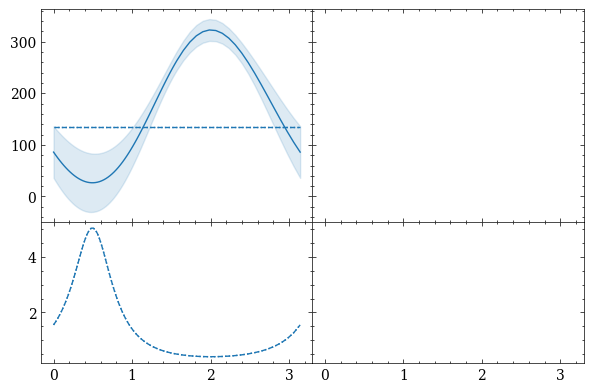

In [1]:
import os, sys, joblib
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa

sys.path.insert(0, '/mnt/users/darnej/MPhys/RARinterpret')
import RARinterpret

_gc_dir    = '/mnt/users/darnej/MPhys/RARinterpret/results/gencomb'
_plots_dir = '/mnt/users/darnej/MPhys/RARinterpret/plots'

# ── Feature keys (must match what run_fig7_gencomb.py saved) ─────────────────
left_keys  = ['gbar', 'SB', 'L36']
right_keys = ['type', 'MHI', 'Reff', 'gbar,SB', 'gbar,SB,MHI',
               'gbar,SB,dist,inc,L36,MHI,type,Reff,log_eN_noclust']


def read_gencomb(feat_key, source):
    """Load (thetas, mu, std) for a feature key and source.

    SPARC scores shape  : (ngrid, n_splits)          -> mean over splits
    Mock scores shape   : (ngrid, n_resample, n_splits) -> mean over both
    """
    if source == 'sparc':
        fpath = os.path.join(_gc_dir, f'ET_{feat_key}.p')
    elif source == 'rar':
        fpath = os.path.join(_gc_dir, f'mock_ET_{feat_key}.p')
    else:  # sbjobs
        fpath = os.path.join(_gc_dir, f'mock_ETSB-Jobs_{feat_key}.p')

    d = joblib.load(fpath)
    s = d['scores']
    mu  = np.mean(s, axis=-1)   # mean over n_splits -> (ngrid,) or (ngrid, n_res)
    std = np.std(s,  axis=-1)
    if mu.ndim == 2:             # mock: also average over n_resample
        mu  = np.mean(mu,  axis=-1)
        std = np.mean(std, axis=-1)
    return d['thetas'], mu, std


def make_label(key):
    parts = key.split(',')
    labels = RARinterpret.pretty_label(parts, RARinterpret.names)
    if len(labels) == 1:
        return labels[0]
    if key == 'gbar,SB':
        return r'$g_{\rm bar},\,\Sigma_{\rm tot}$'
    if key == 'gbar,SB,MHI':
        return r'$g_{\rm bar},\,\Sigma_{\rm tot},\,M_{\rm HI}$'
    return 'All'


cols = plt.rcParams['axes.prop_cycle'].by_key()['color']

with plt.style.context(['science', {'text.usetex': False}]):
    fig, axs = plt.subplots(
        nrows=2, ncols=2,
        figsize=(2 * 3.5, 2.625 * 1.75),
        sharey='row', sharex=True,
        gridspec_kw={'height_ratios': [1, 2 / 3]}
    )
    fig.subplots_adjust(wspace=0, hspace=0)

    # ── Left panel: gbar, SB, L36 ─────────────────────────────────────────────
    for k, feat_key in enumerate(left_keys):
        c = cols[k % len(cols)]
        xrange, mu_s, std_s = read_gencomb(feat_key, 'sparc')
        label = RARinterpret.pretty_label(feat_key, RARinterpret.names)
        axs[0, 0].plot(xrange, mu_s, c=c, label=label)
        axs[0, 0].fill_between(xrange, mu_s - std_s, mu_s + std_s,
                               color=c, alpha=0.15)

        # Mock RAR — dashed
        _, mu_r, _ = read_gencomb(feat_key, 'rar')
        axs[0, 0].plot(xrange, mu_r, c=c, ls='dashed',
                       label='Mock RAR' if k == 0 else None)
        axs[1, 0].plot(xrange, mu_r / mu_s, c=c, ls='dashed',
                       label='Mock RAR' if k == 0 else None)

        # Mock SB-Jobs — dotted
        _, mu_sb, _ = read_gencomb(feat_key, 'sbjobs')
        axs[0, 0].plot(xrange, mu_sb, c=c, ls='dotted',
                       label=r'Mock $\Sigma_{\rm tot} - J_{\rm obs}$' if k == 0 else None)
        axs[1, 0].plot(xrange, mu_sb / mu_s, c=c, ls='dotted',
                       label=r'Mock $\Sigma_{\rm tot} - J_{\rm obs}$' if k == 0 else None)

    # ── Right panel: secondary features ──────────────────────────────────────
    for k, feat_key in enumerate(right_keys):
        c = cols[(k + len(left_keys)) % len(cols)]
        xrange, mu_s, _ = read_gencomb(feat_key, 'sparc')
        axs[0, 1].plot(xrange, mu_s, c=c, label=make_label(feat_key))

        _, mu_r, _ = read_gencomb(feat_key, 'rar')
        axs[0, 1].plot(xrange, mu_r, c=c, ls='dashed')
        axs[1, 1].plot(xrange, mu_r / mu_s, c=c, ls='dashed')

    # ── Shared formatting ─────────────────────────────────────────────────────
    for col_i in range(2):
        secax = axs[0, col_i].secondary_xaxis('top')
        secax.set_xticks([np.arctan(0),
                          np.arctan(1 / 2) - 0.05,
                          np.arctan(2 / 3) + 0.05])
        secax.set_xticklabels(
            [r'$V_{\rm obs}$', r'$g_{\rm obs}$', r'$J_{\rm obs}$'],
            rotation=70)
        for kv in range(3):
            v = np.arctan(kv / (kv + 1))
            axs[0, col_i].axvline(v, c='lightsteelblue', ls='solid', zorder=0, lw=0.6)
            axs[1, col_i].axvline(v, c='lightsteelblue', ls='solid', zorder=0, lw=0.6)
        axs[1, col_i].axhline(1, c='lightsteelblue', ls='solid', zorder=0, lw=0.6)
        axs[1, col_i].set_xlim(0, np.pi)
        axs[1, col_i].set_xlabel(r'$\theta~[{\rm rad}]$')
        axs[0, col_i].set_yscale('log')

    axs[1, 0].axhline(1, c=cols[0], ls='solid', zorder=-1, lw=0.6, label='SPARC')
    axs[0, 0].legend(loc='lower right', ncol=1, handletextpad=0.2,
                     fontsize='small', handlelength=1.5, borderaxespad=0.25)
    axs[1, 0].legend(loc='upper right', ncol=2, handletextpad=0.2,
                     fontsize='small', handlelength=1.5,
                     columnspacing=0.1, borderaxespad=0.25)
    axs[0, 1].legend(loc='lower right', ncol=2, handletextpad=0.2,
                     fontsize='small', handlelength=1.5, borderaxespad=0.25)
    axs[0, 0].set_ylabel(r'Loss $\mathcal{L}_0$ per observation')
    axs[1, 0].set_ylabel(r'$\mathcal{L}_{\rm SPARC} / \mathcal{L}_{\rm mock}$')
    axs[1, 0].set_ylim(0.1, 3.2)

    fig.tight_layout(w_pad=0.0, h_pad=0.0)
    os.makedirs(_plots_dir, exist_ok=True)
    plt.savefig(f'{_plots_dir}/fig7_gencomb.png', dpi=200, bbox_inches='tight')
    plt.show()

print(f'Figure 7 saved to {_plots_dir}/fig7_gencomb.png')